# 01 — Collecte et sources des données

## Projet
**Observatoire de Data Science et de l’IA : ingénierie de la donnée et analyse prédictive de l’évolution des compétences IA par le Web Mining**

## Objectif de ce notebook
Ce notebook présente la partie **collecte et sources des données**.  
Il sert à expliquer :

- les fichiers utilisés ;
- les sources de données ;
- les périodes couvertes ;
- les pays représentés ;
- la taille du dataset final ;
- les fichiers gardés et ignorés ;
- les premières limites des sources.

> Remarque : ce notebook ne refait pas tout le scraping. Il documente et vérifie les données finales déjà consolidées.


---
# 1. Importation des bibliothèques

In [20]:
import warnings

warnings.filterwarnings("ignore")

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 120)

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


---
# 2. Chargement du dataset final clean

Le fichier principal utilisé dans la suite du projet est :

```text
final_data_ai_jobs_clean_2020_2026.csv
```

Il regroupe les offres Data/IA issues de plusieurs sources, après standardisation et nettoyage.


In [22]:
# Chemin du fichier final clean
file_path = "final_data_ai_jobs_clean_2020_2026.csv"

df = pd.read_csv(file_path)

print("Nombre total de lignes :", df.shape[0])
print("Nombre total de colonnes :", df.shape[1])

df.head(3)

Nombre total de lignes : 751801
Nombre total de colonnes : 30


,source,platform,job_id,job_title,company_name,country,city,date_posted,year,month,year_month,job_type,remote_status,experience_level,education_required,industry,category,description,skills,tools_used,salary,salary_currency,job_url,original_file,country_clean,skills_clean,skills_original,remote_status_clean,remote_status_original,job_category_clean
0,global_ai_jobs_dataset,Synthetic / Global,1,AI Researcher,NaN,Canada,Berlin,2021-04-01 00:00:00,2021,4.0,2021-04,NaN,Remote,Senior,PhD,Manufacturing,Generative AI,NaN,"python, computer vision, sql, nlp",Kubernetes;PyTorch;AWS,104015,USD,NaN,global_ai_jobs_dataset.csv,Canada,"python, computer vision, sql, nlp",Python;Computer Vision;SQL;NLP,Remote,Remote,Machine Learning / AI
1,global_ai_jobs_dataset,Synthetic / Global,2,MLOps Engineer,NaN,India,Tokyo,2020-04-12 00:00:00,2020,4.0,2020-04,NaN,Remote,Entry,Bachelor,Education,Recommendation Systems,NaN,"nlp, pytorch, data analysis, computer vision",Python;Spark;Docker,103263,USD,NaN,global_ai_jobs_dataset.csv,India,"nlp, pytorch, data analysis, computer vision",NLP;PyTorch;Data Analysis;Computer Vision,Remote,Remote,MLOps / Cloud Data
2,global_ai_jobs_dataset,Synthetic / Global,3,Data Analyst,NaN,United Kingdom,Bangalore,2023-01-31 00:00:00,2023,1.0,2023-01,NaN,Hybrid,Mid,Bachelor,E-commerce,Robotics,NaN,"nlp, computer vision, python, pytorch",Python;Kubernetes;PyTorch,104190,USD,NaN,global_ai_jobs_dataset.csv,United Kingdom,"nlp, computer vision, python, pytorch",NLP;Computer Vision;Python;PyTorch,Hybrid,Hybrid,Data Analysis / BI


---
# 3. Colonnes disponibles dans le dataset final

In [23]:
print("Colonnes du dataset final :")
for col in df.columns:
    print("-", col)

Colonnes du dataset final :
- source
- platform
- job_id
- job_title
- company_name
- country
- city
- date_posted
- year
- month
- year_month
- job_type
- remote_status
- experience_level
- education_required
- industry
- category
- description
- skills
- tools_used
- salary
- salary_currency
- job_url
- original_file
- country_clean
- skills_clean
- skills_original
- remote_status_clean
- remote_status_original
- job_category_clean


## Description rapide des colonnes principales

| Colonne | Description |
|---|---|
| `source` | Source technique ou nom interne de la source |
| `platform` | Plateforme ou type de source |
| `job_id` | Identifiant de l’offre |
| `job_title` | Titre du poste |
| `company_name` | Nom de l’entreprise |
| `country` | Pays de l’offre |
| `city` | Ville ou localisation |
| `date_posted` | Date de publication de l’offre |
| `year`, `month`, `year_month` | Variables temporelles dérivées |
| `job_type` | Type de contrat ou rythme de travail |
| `remote_status` | Remote / Hybrid / On-site / Not specified |
| `experience_level` | Niveau d’expérience quand disponible |
| `education_required` | Niveau d’éducation quand disponible |
| `industry` | Secteur d’activité quand disponible |
| `category` | Catégorie ou famille du poste |
| `description` | Description de l’offre quand disponible |
| `skills` | Compétences détectées ou fournies |
| `tools_used` | Outils ou technologies quand disponibles |
| `salary` | Salaire quand disponible |
| `salary_currency` | Devise du salaire |
| `job_url` | Lien de l’offre |
| `original_file` | Fichier d’origine |


---
# 4. Période couverte par les données

In [24]:
df["date_posted"] = pd.to_datetime(df["date_posted"], errors="coerce")

print("Date minimale :", df["date_posted"].min())
print("Date maximale :", df["date_posted"].max())
print("Nombre de dates manquantes :", df["date_posted"].isna().sum())

Date minimale : 2020-01-01 00:00:00
Date maximale : 2026-05-06 16:47:40
Nombre de dates manquantes : 1240


---
# 5. Répartition des offres par année

In [25]:
offers_by_year = (
    df["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

offers_by_year.columns = ["year", "number_of_jobs"]
offers_by_year

,year,number_of_jobs
0,2020,20010
1,2021,20175
2,2022,19872
3,2023,641784
4,2024,27642
5,2025,20985
6,2026,1333


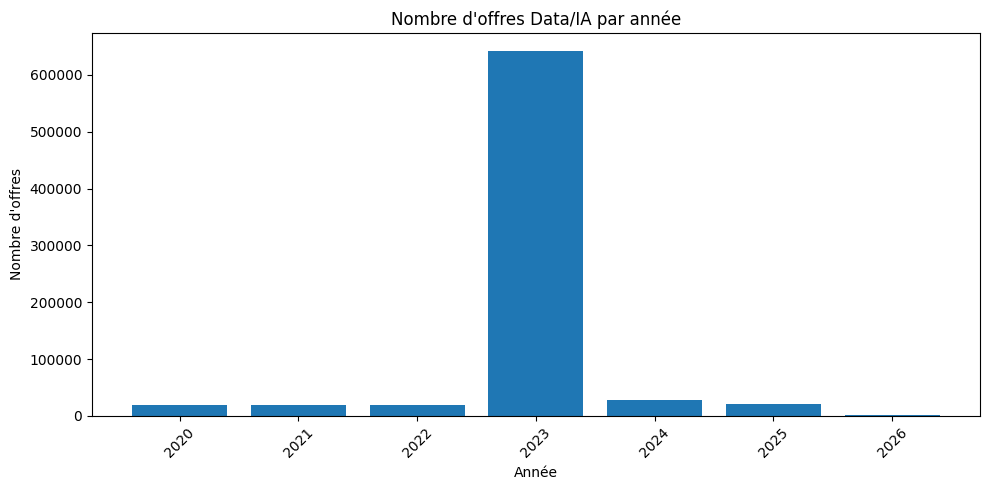

In [26]:
plt.figure(figsize=(10, 5))
plt.bar(offers_by_year["year"].astype(str), offers_by_year["number_of_jobs"])
plt.title("Nombre d'offres Data/IA par année")
plt.xlabel("Année")
plt.ylabel("Nombre d'offres")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interprétation

La période couverte va de **2020 à 2026**.  
On remarque que l’année **2023** est très dominante, car elle contient la grande source Hugging Face `data_jobs`.  
Cela montre que le dataset est riche, mais aussi **déséquilibré par année**. Les analyses temporelles doivent donc être interprétées avec prudence.


---
# 6. Répartition des offres par fichier source

In [27]:
sources_count = (
    df["original_file"]
    .value_counts()
    .reset_index()
)

sources_count.columns = ["original_file", "number_of_jobs"]
sources_count["percentage"] = round(sources_count["number_of_jobs"] / len(df) * 100, 2)

sources_count

,original_file,number_of_jobs,percentage
0,huggingface_global_2023_data_jobs_skills_filtered.csv,622067,82.74
1,global_ai_jobs_dataset.csv,120000,15.96
2,linkedin_us_uk_canada_australia_2024-01-12_to_2024-01-17_data_ai_skills_filtered.csv,5732,0.76
3,linkedin_datastax_2023-12-05_to_2024-04-20_data_ai_filtered.csv,1777,0.24
4,jobs_raw.json,960,0.13
5,kaggle_global_2025_data_science_jobs_skills_filtered.csv,941,0.13
6,jobs_data_ai_clean.csv,274,0.04
7,aijobs_raw.csv,50,0.01


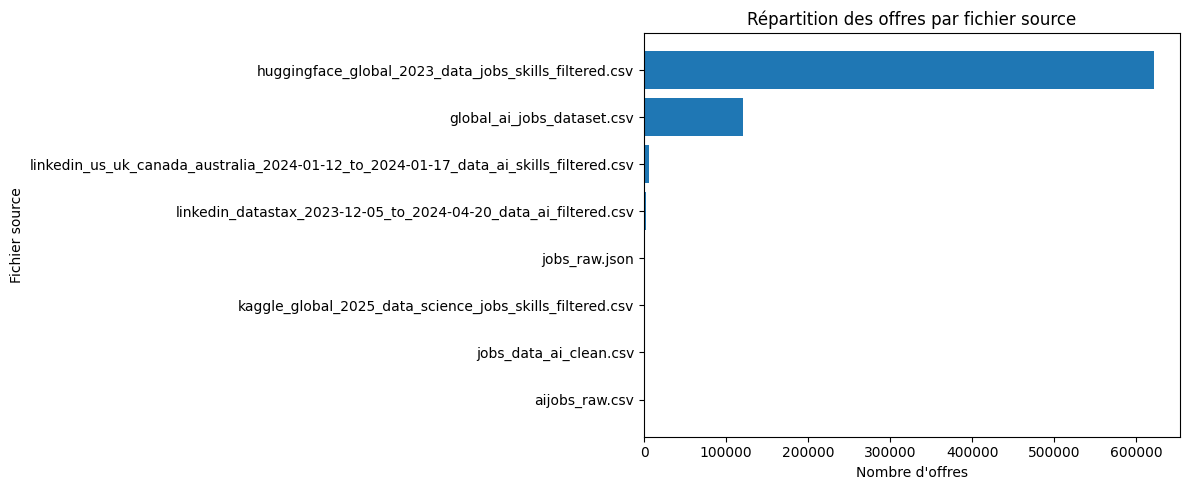

In [28]:
plt.figure(figsize=(12, 5))
plt.barh(sources_count["original_file"], sources_count["number_of_jobs"])
plt.title("Répartition des offres par fichier source")
plt.xlabel("Nombre d'offres")
plt.ylabel("Fichier source")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interprétation

La source `huggingface_global_2023_data_jobs_skills_filtered.csv` représente la majorité des offres.  
Cela crée un **biais de volume** : les résultats globaux peuvent être fortement influencés par cette source.  
Pour éviter des conclusions fausses, les analyses suivantes devront aussi utiliser des proportions et des fréquences relatives.


---
# 7. Tableau récapitulatif des sources utilisées

In [29]:
sources_summary = pd.DataFrame({
    "fichier": [
        "global_ai_jobs_dataset.csv",
        "jobs_data_ai_clean.csv",
        "kaggle_global_2025_data_science_jobs_skills_filtered.csv",
        "linkedin_us_uk_canada_australia_2024-01-12_to_2024-01-17_data_ai_skills_filtered.csv",
        "huggingface_global_2023_data_jobs_skills_filtered.csv",
        "linkedin_datastax_2023-12-05_to_2024-04-20_data_ai_filtered.csv",
        "jobs_raw.json",
        "aijobs_raw.csv",
        "remoteok_raw.csv"
    ],
    "type_source": [
        "Dataset externe",
        "Scraping multi-sources",
        "Dataset Kaggle",
        "Dataset LinkedIn avec skills",
        "Dataset Hugging Face",
        "Dataset LinkedIn Hugging Face",
        "API / scraping jobs",
        "Scraping ai-jobs.net",
        "Scraping RemoteOK"
    ],
    "periode": [
        "2020-2026",
        "2025-2026",
        "2025",
        "2024-01-12 à 2024-01-17",
        "2023",
        "2023-12-05 à 2024-04-20",
        "2026-04-15 à 2026-05-15",
        "2026",
        "2026"
    ],
    "nombre_lignes_utilisees": [
        120000,
        274,
        941,
        5732,
        622067,
        1777,
        960,
        50,
        0
    ],
    "statut": [
        "Gardé",
        "Gardé",
        "Gardé",
        "Gardé",
        "Gardé",
        "Gardé",
        "Gardé",
        "Gardé",
        "Ignoré"
    ],
    "raison": [
        "Dataset historique global AI/Data avec skills",
        "Offres récentes multi-plateformes, déjà nettoyées",
        "Offres Data Science 2025 avec skills",
        "Offres LinkedIn 2024 avec pays et skills",
        "Grande base Data Jobs 2023 avec skills",
        "Offres LinkedIn filtrées Data/AI avec descriptions",
        "Offres récentes Data/AI avec descriptions",
        "Offres spécialisées AI jobs avec skills",
        "Pays non fiable ou absent"
    ]
})

sources_summary

,fichier,type_source,periode,nombre_lignes_utilisees,statut,raison
0,global_ai_jobs_dataset.csv,Dataset externe,2020-2026,120000,Gardé,Dataset historique global AI/Data avec skills
1,jobs_data_ai_clean.csv,Scraping multi-sources,2025-2026,274,Gardé,"Offres récentes multi-plateformes, déjà nettoyées"
2,kaggle_global_2025_data_science_jobs_skills_filtered.csv,Dataset Kaggle,2025,941,Gardé,Offres Data Science 2025 avec skills
3,linkedin_us_uk_canada_australia_2024-01-12_to_2024-01-17_data_ai_skills_filtered.csv,Dataset LinkedIn avec skills,2024-01-12 à 2024-01-17,5732,Gardé,Offres LinkedIn 2024 avec pays et skills
4,huggingface_global_2023_data_jobs_skills_filtered.csv,Dataset Hugging Face,2023,622067,Gardé,Grande base Data Jobs 2023 avec skills
5,linkedin_datastax_2023-12-05_to_2024-04-20_data_ai_filtered.csv,Dataset LinkedIn Hugging Face,2023-12-05 à 2024-04-20,1777,Gardé,Offres LinkedIn filtrées Data/AI avec descriptions
6,jobs_raw.json,API / scraping jobs,2026-04-15 à 2026-05-15,960,Gardé,Offres récentes Data/AI avec descriptions
7,aijobs_raw.csv,Scraping ai-jobs.net,2026,50,Gardé,Offres spécialisées AI jobs avec skills
8,remoteok_raw.csv,Scraping RemoteOK,2026,0,Ignoré,Pays non fiable ou absent


In [30]:
sources_summary.to_csv("sources_summary.csv", index=False, encoding="utf-8-sig")
print("Fichier sauvegardé : sources_summary.csv")

Fichier sauvegardé : sources_summary.csv


---
# 8. Pays présents dans le dataset

In [31]:
countries_count = (
    df["country"]
    .value_counts(dropna=False)
    .reset_index()
)

countries_count.columns = ["country", "number_of_jobs"]
countries_count["percentage"] = round(countries_count["number_of_jobs"] / len(df) * 100, 2)

print("Nombre de pays différents :", df["country"].nunique(dropna=True))
print("Nombre de pays manquants :", df["country"].isna().sum())

countries_count.head(50)

Nombre de pays différents : 164
Nombre de pays manquants : 265


,country,number_of_jobs,percentage
0,United States,199743,26.57
1,India,56012,7.45
2,United Kingdom,46123,6.14
3,Germany,33488,4.45
4,France,32273,4.29
5,Singapore,31216,4.15
6,Netherlands,28268,3.76
7,Canada,25601,3.41
8,Australia,21516,2.86
9,Spain,20278,2.70


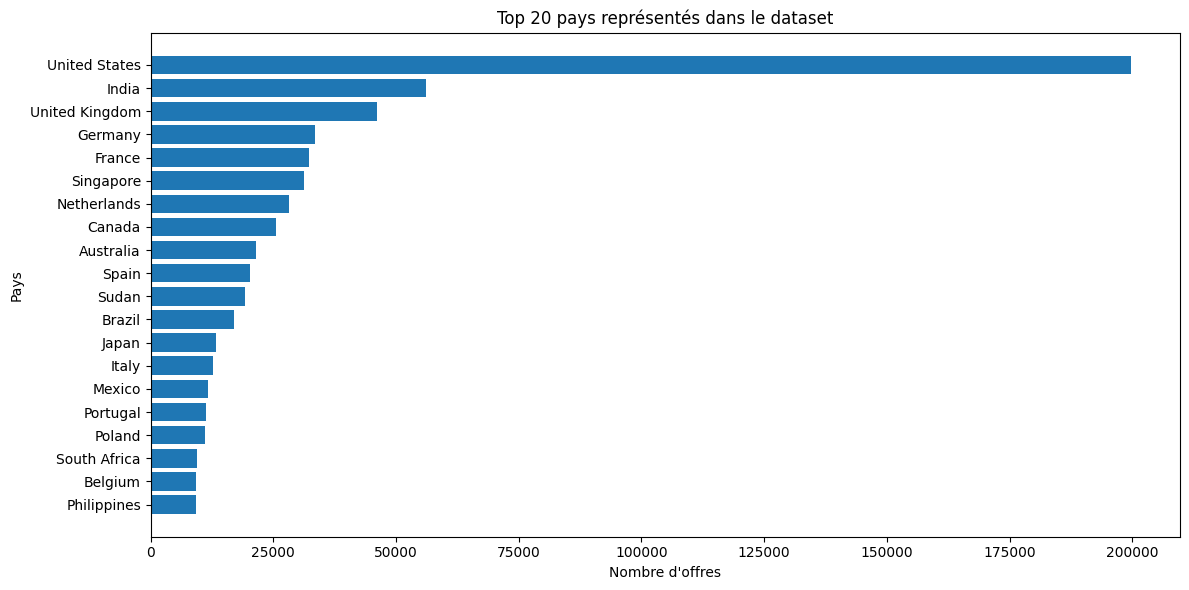

In [32]:
top_countries = countries_count.head(20)

plt.figure(figsize=(12, 6))
plt.barh(top_countries["country"].astype(str), top_countries["number_of_jobs"])
plt.title("Top 20 pays représentés dans le dataset")
plt.xlabel("Nombre d'offres")
plt.ylabel("Pays")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interprétation

Le dataset est principalement international. Les pays les plus représentés sont notamment les **États-Unis**, l’**Inde**, le **Royaume-Uni**, l’**Allemagne** et la **France**.  
Le **Maroc** est présent, mais avec un volume beaucoup plus faible que les grands pays. Cela devra être mentionné comme une limite de représentativité.


---
# 9. Focus sur le Maroc

In [33]:
df_morocco = df[df["country"] == "Morocco"]

print("Nombre d'offres localisées au Maroc :", df_morocco.shape[0])

print("\nRépartition Maroc par année :")
print(df_morocco["year"].value_counts().sort_index())

print("\nSources des offres Maroc :")
print(df_morocco["original_file"].value_counts())

print("\nTop 30 titres au Maroc :")
print(df_morocco["job_title"].value_counts().head(30))

Nombre d'offres localisées au Maroc : 1058

Répartition Maroc par année :
year
2023    909
2025      3
2026    146
Name: count, dtype: int64

Sources des offres Maroc :
original_file
huggingface_global_2023_data_jobs_skills_filtered.csv    909
jobs_raw.json                                             75
jobs_data_ai_clean.csv                                    74
Name: count, dtype: int64

Top 30 titres au Maroc :
job_title
Data Engineer                                                                     84
Data Scientist                                                                    42
Data Analyst                                                                      39
Senior Data Engineer                                                              23
Senior Data Scientist                                                             21
Data scientist                                                                    18
Data Engineer (H/F)                                           

### Interprétation

Le Maroc représente une petite partie du dataset global.  
Cette partie sera utile pour un **focus Maroc**, mais les comparaisons avec les grands pays doivent être faites avec prudence, car le dataset est déséquilibré par pays.


---
# 10. Plateformes de collecte

In [34]:
platforms_count = (
    df["platform"]
    .value_counts(dropna=False)
    .reset_index()
)

platforms_count.columns = ["platform", "number_of_jobs"]
platforms_count["percentage"] = round(platforms_count["number_of_jobs"] / len(df) * 100, 2)

platforms_count

,platform,number_of_jobs,percentage
0,Hugging Face,622067,82.74
1,Synthetic / Global,120000,15.96
2,LinkedIn,7509,1.00
3,JSearch/RapidAPI,960,0.13
4,Kaggle,941,0.13
5,ai-jobs.net,149,0.02
6,We Work Remotely,54,0.01
7,aijobs.net,50,0.01
8,RemoteOK,35,0.00
9,Emploi.ma,35,0.00


---
# 11. Disponibilité des compétences

In [35]:
print("Offres avec skills :", df["skills"].notna().sum())
print("Offres sans skills :", df["skills"].isna().sum())
print("Pourcentage avec skills :", round(df["skills"].notna().mean() * 100, 2), "%")

df[["job_title", "country", "year", "skills"]].head(10)

Offres avec skills : 751476
Offres sans skills : 325
Pourcentage avec skills : 99.96 %


,job_title,country,year,skills
0,AI Researcher,Canada,2021,"python, computer vision, sql, nlp"
1,MLOps Engineer,India,2020,"nlp, pytorch, data analysis, computer vision"
2,Data Analyst,United Kingdom,2023,"nlp, computer vision, python, pytorch"
3,NLP Engineer,Brazil,2022,"data analysis, statistics, tensorflow, python"
4,AI Researcher,Netherlands,2022,"nlp, machine learning, pytorch, sql"
5,Prompt Engineer,Brazil,2021,"tensorflow, computer vision, nlp, machine learning"
6,AI Engineer,Singapore,2021,"statistics, python, tensorflow, machine learning"
7,AI Researcher,Brazil,2020,"computer vision, deep learning, tensorflow, pytorch"
8,Data Analyst,United States,2024,"statistics, machine learning, computer vision, sql"
9,NLP Engineer,Singapore,2020,"deep learning, machine learning, sql, pytorch"


### Interprétation

La colonne `skills` est essentielle pour la suite du projet, car elle permet :

- l’analyse des compétences les plus demandées ;
- le Web Content Mining ;
- le Graph Mining ;
- la prédiction de l’évolution des compétences ;
- le dashboard des skills.

La très grande majorité des offres possède des compétences exploitables.


---
# 12. Statut remote / hybrid / on-site

In [36]:
remote_count = (
    df["remote_status"]
    .value_counts(dropna=False)
    .reset_index()
)

remote_count.columns = ["remote_status", "number_of_jobs"]
remote_count["percentage"] = round(remote_count["number_of_jobs"] / len(df) * 100, 2)

remote_count

,remote_status,number_of_jobs,percentage
0,On-site,608492,80.94
1,Remote,100902,13.42
2,Hybrid,40077,5.33
3,Not specified,2330,0.31


---
# 13. Titres de postes les plus fréquents

In [37]:
top_titles = (
    df["job_title"]
    .value_counts()
    .head(50)
    .reset_index()
)

top_titles.columns = ["job_title", "number_of_jobs"]

top_titles

,job_title,number_of_jobs
0,Data Engineer,50856
1,Data Scientist,49939
2,Data Analyst,47698
3,Senior Data Engineer,19672
4,Machine Learning Engineer,14948
5,MLOps Engineer,12305
6,Prompt Engineer,12189
7,Senior Data Scientist,12177
8,AI Researcher,12121
9,NLP Engineer,12069


---
# 14. Résumé global automatique

In [38]:
print("===== RÉSUMÉ GLOBAL DU DATASET =====")

print("\n1. Dimensions")
print("Nombre d'offres :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

print("\n2. Période")
print("Date minimale :", df["date_posted"].min())
print("Date maximale :", df["date_posted"].max())

print("\n3. Offres par année")
print(df["year"].value_counts().sort_index())

print("\n4. Top 10 pays")
print(df["country"].value_counts(dropna=False).head(10))

print("\n5. Nombre de pays différents")
print(df["country"].nunique(dropna=True))

print("\n6. Sources")
print(df["original_file"].value_counts())

print("\n7. Remote status")
print(df["remote_status"].value_counts(dropna=False))

print("\n8. Skills")
print("Offres avec skills :", df["skills"].notna().sum())
print("Offres sans skills :", df["skills"].isna().sum())

print("\n9. Maroc")
print("Offres Maroc :", (df["country"] == "Morocco").sum())

print("\n10. Qualité de base")
print("Dates manquantes :", df["date_posted"].isna().sum())
print("Pays manquants :", df["country"].isna().sum())
print("Skills manquantes :", df["skills"].isna().sum())

===== RÉSUMÉ GLOBAL DU DATASET =====

1. Dimensions
Nombre d'offres : 751801
Nombre de colonnes : 30

2. Période
Date minimale : 2020-01-01 00:00:00
Date maximale : 2026-05-06 16:47:40

3. Offres par année
year
2020     20010
2021     20175
2022     19872
2023    641784
2024     27642
2025     20985
2026      1333
Name: count, dtype: int64

4. Top 10 pays
country
United States     199743
India              56012
United Kingdom     46123
Germany            33488
France             32273
Singapore          31216
Netherlands        28268
Canada             25601
Australia          21516
Spain              20278
Name: count, dtype: int64

5. Nombre de pays différents
164

6. Sources
original_file
huggingface_global_2023_data_jobs_skills_filtered.csv                                   622067
global_ai_jobs_dataset.csv                                                              120000
linkedin_us_uk_canada_australia_2024-01-12_to_2024-01-17_data_ai_skills_filtered.csv      5732
linkedin_data

---
# 15. Conclusion de la collecte

Les données collectées proviennent de sources multiples : datasets publics, plateformes d’offres d’emploi, scraping et API.  
Après sélection, les sources retenues ont été consolidées dans un dataset final couvrant la période **2020–2026**.

Le dataset final est adapté au projet car il contient les éléments nécessaires :

- le titre du poste ;
- la date ;
- le pays ;
- les compétences ;
- la source ;
- le mode de travail ;
- parfois la description et le salaire.

Cependant, la collecte présente certaines limites :

- le dataset est déséquilibré par source ;
- l’année 2023 est dominante ;
- les États-Unis et les pays anglophones sont très représentés ;
- le Maroc est présent mais minoritaire ;
- certaines colonnes comme salaire, description ou URL ne sont pas disponibles dans toutes les sources.

Ces limites seront analysées plus en détail dans le notebook suivant consacré au **Data Quality Framework**.
